In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import json
from ipysigma import Sigma

In [ ]:
BlastPairWiseAlignmentPivoted = pd.read_csv("../data/processed/BlastPairWiseAlignmentPivoted.cov80.maxseq1.csv", sep="\t")
mask = np.triu(np.ones_like(BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"), dtype=bool)) 
sns.heatmap(
    BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"),
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidth=.5,
    mask=mask,
)
plt.title("Databases Redudancy (>95% identity)")

In [ ]:
BlastPairWiseAlignmentPivoted

In [ ]:
ClustersCdHit = pd.read_csv(
    "../data/processed/cdhitclusters.defaultsettings.csv",
    sep = "\t",
)
sns.lineplot(
    ClustersCdHit.set_index("Unnamed: 0"),
    marker = "o"
)
plt.xlabel("Identity Threshold (%)")
plt.ylabel("Database Size")

In [ ]:
ClustersCdHit

In [23]:
PairWiseAlignment = pd.read_csv(
    "../data/filtered/AllDatabases.Paiwise.cov80.maxseq5.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
PairWiseAlignment["qcov"] = np.round((PairWiseAlignment["qend"] - PairWiseAlignment["qstart"] + 1) / (PairWiseAlignment["qlen"]) * 100, 2)
PairWiseAlignment["scov"] = np.round((PairWiseAlignment["send"] - PairWiseAlignment["sstart"] + 1) / (PairWiseAlignment["slen"]) * 100, 2)
PairWiseAlignment["qseqtag"] = PairWiseAlignment["qseqid"].str.split("|").str[1]
PairWiseAlignment["sseqtag"] = PairWiseAlignment["sseqid"].str.split("|").str[1]
PairWiseAlignment["qseqid"] = PairWiseAlignment["qseqid"].str.split("|").str[0]
PairWiseAlignment["sseqid"] = PairWiseAlignment["sseqid"].str.split("|").str[0]

In [30]:
PairWiseAlignment

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,MEGARES
1,CARD_0,MEGARES_1087,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,MEGARES
2,CARD_0,NDARO_1066,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,NDARO
3,CARD_0,NCRD_32754,100.0,296,296,302,1,296,1,296,7.120000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,98.01,CARD,NCRD
4,CARD_0,HMD_10110,99.7,296,296,304,1,296,9,304,2.200000e-214,585.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MPLKEIEVMKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGK...,100.0,97.37,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380749,RESFINDER_2922,CARD_2551,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,CARD
380750,RESFINDER_2922,MEGARES_948,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,MEGARES
380751,RESFINDER_2922,NCRD_529,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,NCRD
380752,RESFINDER_2922,NDARO_4176,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,NDARO


<Axes: xlabel='qcov', ylabel='pident'>

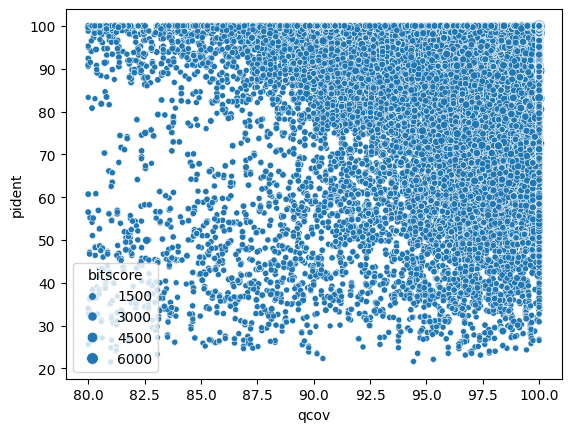

In [24]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="qcov", 
    y="pident",
    size = "bitscore",
    )

In [ ]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="pident", 
    y="ppos",
    size = "bitscore",
    )

In [ ]:
PairWiseAlignment

In [31]:
with open("../data/processed/MetaDict.Cov80.maxseq1.json", "r") as json_file  :
    MetaDict = json.load(json_file)

In [32]:
MetaDict["CARD_0"]

{'Drug Class': 'beta-lactam',
 'Name': 'CblA-1',
 'Sequence': 'MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAVWTDKGDMLRYNDHVHFPLLSVFKFHVALAVLDKMDKQSISLDSIVSIKASQMPPNTYSPLRKKFPDQDFTITLRELMQYSISQSDNNACDILIEYAGGIKHINDYIHRLSIDSFNLSETEDGMHSSFEAVYRNWSTPSAMVRLLRTADEKELFSNKELKDFLWQTMIDTETGANKLKGMLPAKTVVGHKTGSSDRNADGMKTADNDAGLVILPDGRKYYIAAFVMDSYETDEDNANIIARISRMVYDAMR'}

In [33]:
SequenceSimilarityGraph = nx.from_pandas_edgelist(
    PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    source="qseqid", 
    target="sseqid", 
    edge_attr=["pident", "bitscore", "evalue","bitscore", "ppos"]
)

In [34]:
nx.set_node_attributes(SequenceSimilarityGraph, MetaDict)

In [ ]:
SequenceSimilarityGraph.nodes["CARD_0"]

In [35]:
ConnectedComponents = list(nx.connected_components(SequenceSimilarityGraph))
len(ConnectedComponents)

1930

In [39]:
ProblematicComponents = set()
for i, component in enumerate(ConnectedComponents):
    ComponentGraph = SequenceSimilarityGraph.subgraph(component)
    Classes = [ComponentGraph.nodes[n].get("Drug Class") for n in component]
    if len(set(Classes)) > 1 and len(component) > 4430:
        print(len(component))
        ProblematicComponents = ProblematicComponents.union(component)

4438


In [40]:
ComponentGraph = SequenceSimilarityGraph.subgraph(ProblematicComponents)

meu_layout = {
    "scalingRatio": 50.0,           # Aumente para afastar os grupos
    "gravity": 0.2,                 # Reduza para não amontoar no centro
    # "outboundAttractionDistribution": True, # Empurra hubs para fora
    # "barnesHutOptimize": True,      # Essencial para seus 70k nós
    # "linLogMode": True              # Melhora a definição de clusters biológicos
}
Sigma(
    ComponentGraph, 
    node_size  = ComponentGraph.degree(), 
    node_color =  [ComponentGraph.nodes[n].get("Drug Class") for n in ComponentGraph.nodes()],
    # node_metrics={"community": "louvain"},

    default_edge_type = "curve",
    layout_settings=meu_layout,
    # start_layout=20,
    )

Sigma(nx.Graph with 4,438 nodes and 16,144 edges)

In [ ]:
SequenceSimilarityGraph.nodes["CARD_0"].get("Drug Class")

In [ ]:
Degree = nx.degree_centrality(SequenceSimilarityGraph)
TopHubs = sorted(Degree.items(), key=lambda x: x[1], reverse=True)[:10]
TopHubs

In [ ]:
Bridges = list(nx.bridges(SequenceSimilarityGraph))
len(Bridges)

In [ ]:
ArtPoints = list(nx.articulation_points(SequenceSimilarityGraph))
len(ArtPoints)

In [ ]:
BetweennessCentrality = nx.betweenness_centrality(SequenceSimilarityGraph)
TopBetweenness = sorted(BetweennessCentrality.items(), key=lambda x: x[1], reverse=True)[:10]
TopBetweenness